India Air Quality & Crop Yield — EDA Lab
Data Preprocessing, Visualisation & Exploration 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

city = pd.read_csv('city_day.csv')
crop= pd.read_csv('crop_production.csv')


In [3]:
city.head()


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [4]:
crop.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [19]:
print("City Dataset Shape:", city.shape)
print("Crop Dataset Shape:", crop.shape)


City Dataset Shape: (29531, 16)
Crop Dataset Shape: (246091, 7)


City dataset contains 29,531 rows and 16 columns.
Crop dataset contains 246,091 rows and 7 columns.

In [20]:
# check column names
print("City Columns:")
print(city.columns)

print("\nCrop Columns:")
print(crop.columns)

City Columns:
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Crop Columns:
Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')


In [ ]:
city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [16]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [21]:
# check for missing values
print("Missing values in City dataset:")
print(city.isnull().sum())

print("\nMissing values in Crop dataset:")
print(crop.isnull().sum())

Missing values in City dataset:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Missing values in Crop dataset:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


In [10]:
city.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [18]:
crop.describe()

,Crop_Year,Area,Production
count,246091.000000,2.460910e+05,2.423610e+05
mean,2005.643018,1.200282e+04,5.825034e+05
std,4.952164,5.052340e+04,1.706581e+07
min,1997.000000,4.000000e-02,0.000000e+00
25%,2002.000000,8.000000e+01,8.800000e+01
50%,2006.000000,5.820000e+02,7.290000e+02
75%,2010.000000,4.392000e+03,7.023000e+03
max,2015.000000,8.580100e+06,1.250800e+09


In [22]:
print("City Duplicates:", city.duplicated().sum())
print("Crop Duplicates:", crop.duplicated().sum())

City Duplicates: 0
Crop Duplicates: 0


city dataset
The dataset contains a large number of missing values, especially in Xylene, PM10, NH3, Toluene, and Benzene.
 These missing values may reduce model accuracy if not handled properly.

crop dataset
The Production column contains missing values. Since production is likely the target variable for analysis,
 these missing records must be handled before building a machine learning model.

In [23]:
# task 2
print("Missing values in City dataset:")
print(city.isnull().sum())

print("\nMissing values in Crop dataset:")
print(crop.isnull().sum())

Missing values in City dataset:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Missing values in Crop dataset:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


The City dataset contains missing values in several numerical pollution-related columns and one categorical column (AQI_Bucket). Since deleting all rows with missing values would result in significant data loss

Mean imputation assumes that data is symmetrically distributed and is highly influenced by extreme values. Pollution and crop production data often contain outliers, making median a more reliable choice.

In [24]:
air_num_cols = [
    'PM2.5','PM10','NO','NO2','NOx',
    'NH3','CO','SO2','O3','Benzene',
    'Toluene','Xylene','AQI'
]

for col in air_num_cols:
    city[col] = city[col].fillna(city[col].median())

city['AQI_Bucket'] = city['AQI_Bucket'].fillna(
    city['AQI_Bucket'].mode()[0]
)

crop['Production'] = crop['Production'].fillna(
    crop['Production'].median()
)

In [25]:
print("Missing values in City dataset after treatment:")
print(city.isnull().sum())

print("\nMissing values in Crop dataset after treatment:")
print(crop.isnull().sum())

Missing values in City dataset after treatment:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

Missing values in Crop dataset after treatment:
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


Missing values in numerical columns were replaced with the median value because it is more reliable
when the data contains extreme values. Missing values in AQI_Bucket were replaced with the most
common category. This approach helps keep all records in the dataset while ensuring that no missing values remain.

In [26]:
# task 3
print("City Duplicates:", city.duplicated().sum())
print("Crop Duplicates:", crop.duplicated().sum())

City Duplicates: 0
Crop Duplicates: 0


In [27]:
city_before = len(city)
crop_before = len(crop)

print("City Records Before:", city_before)
print("Crop Records Before:", crop_before)

City Records Before: 29531
Crop Records Before: 246091


In [30]:
city = city.drop_duplicates()
crop = crop.drop_duplicates()

In [31]:
print("City Records After:", len(city))
print("Crop Records After:", len(crop))

City Records After: 29531
Crop Records After: 246091


In [35]:
city_to_state = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

city['State'] = city['City'].map(city_to_state)

print("Unmapped Cities:", city['State'].isnull().sum())

Unmapped Cities: 0


In [36]:
city['State'] = city['State'].str.strip().str.title()
crop['State_Name'] = crop['State_Name'].str.strip().str.title()

This removes extra spaces and standardizes capitalization so that state names match exactly.

## Inconsistencies Found and Fixes Applied

| Inconsistency Found | Fix Applied |

| City dataset contained city names instead of state names | Created a State column using city-to-state mapping |
| Missing mappings for Amritsar and Jorapokhar | Added Punjab and Jharkhand mappings |
| Extra spaces in state names | Removed using str.strip() |
| Different capitalization in state names | Standardized using str.title() |
| Duplicate records | Checked using duplicated() and removed using drop_duplicates() |

Duplicate records were checked and no duplicate rows were found in either dataset. A State column was created in the City dataset using city-to-state mapping. Missing mappings for Amritsar and Jorapokhar were added. State names were standardized by removing extra spaces and correcting capitalization differences. Both datasets now contain a consistent State field and are ready to be merged reliably.

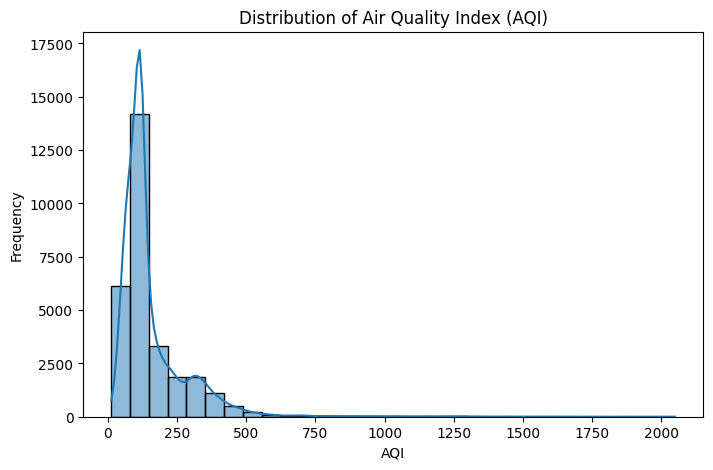

In [ ]:
# task 4
plt.figure(figsize=(8,5))

sns.histplot(city['AQI'], bins=30, kde=True)

plt.title("Distribution of Air Quality Index (AQI)")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

Most AQI values are concentrated below 300, indicating that the majority of cities fall within the low to moderate pollution range.

## Justification for Plot Selection

A histogram was chosen because it shows the overall distribution of AQI values and helps identify where most 
cities are concentrated on the AQI scale.

A boxplot was chosen because it clearly shows the spread of AQI values and reveals the presence of outliers.
This helps determine whether a few extreme cities are influencing the average AQI.

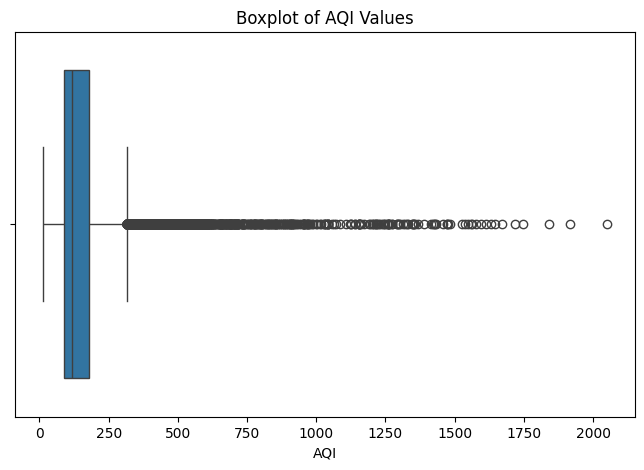

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(x=city['AQI'])

plt.title("Boxplot of AQI Values")

plt.xlabel("AQI")

plt.show()

The boxplot shows several extreme AQI values far above the upper whisker, suggesting that a small number of highly
 polluted cities may increase the overall average AQI

In [42]:
# task 5
Q1 = city['AQI'].quantile(0.25)
Q3 = city['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = city[(city['AQI'] < lower_limit) | (city['AQI'] > upper_limit)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 3192


The IQR method was used because it is a simple and widely accepted technique for detecting extreme values.
 It does not assume that the data follows a normal distribution and works well for skewed data such as AQI.

In [44]:
# Apply Outlier Treatment (Capping)
city['AQI'] = city['AQI'].clip(
    lower=lower_limit,
    upper=upper_limit
)

Capping was chosen instead of deleting records because removing rows would result in loss of information.
 Capping reduces the influence of unrealistic AQI values while keeping all observations.

In [45]:
# Count Values Treated
print("Values Treated:", len(outliers))

Values Treated: 3192


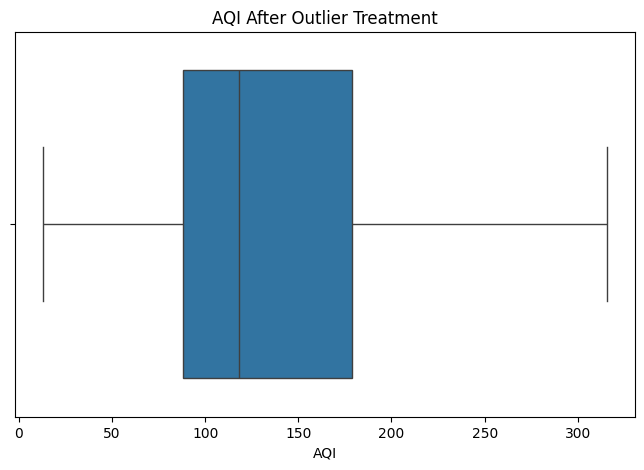

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=city['AQI'])

plt.title("AQI After Outlier Treatment")
plt.xlabel("AQI")

plt.show()

The IQR method was used to detect outliers because it is simple and effective for skewed data.
 Capping was chosen instead of deleting records so that no data was lost while still reducing the effect of extreme 
 AQI values. The before-and-after boxplots confirm that the treatment successfully controlled the outliers.

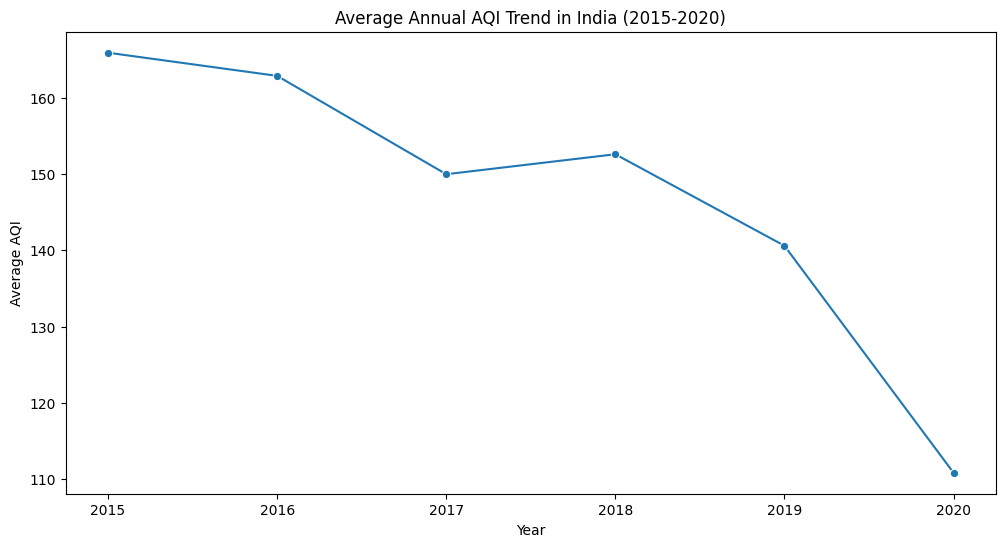

In [47]:
# task 6
city['Date'] = pd.to_datetime(city['Date'])

city['Year'] = city['Date'].dt.year

yearly_aqi = city.groupby('Year')['AQI'].mean().reset_index()

max_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

plt.figure(figsize=(12,6))

sns.lineplot(data=yearly_aqi, x='Year', y='AQI', marker='o')

plt.title('Average Annual AQI Trend in India (2015-2020)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.xticks(yearly_aqi['Year'])

plt.show()

1. Air quality has generally improved over time. The average AQI decreased from about 166 in 2015 
to about 111 in 2020, indicating better air quality in recent years.

2. The most polluted year was 2015, while the least polluted year was 2020. Although there was
 a small increase in AQI during 2018, the overall trend shows a decline in pollution levels.

task 7

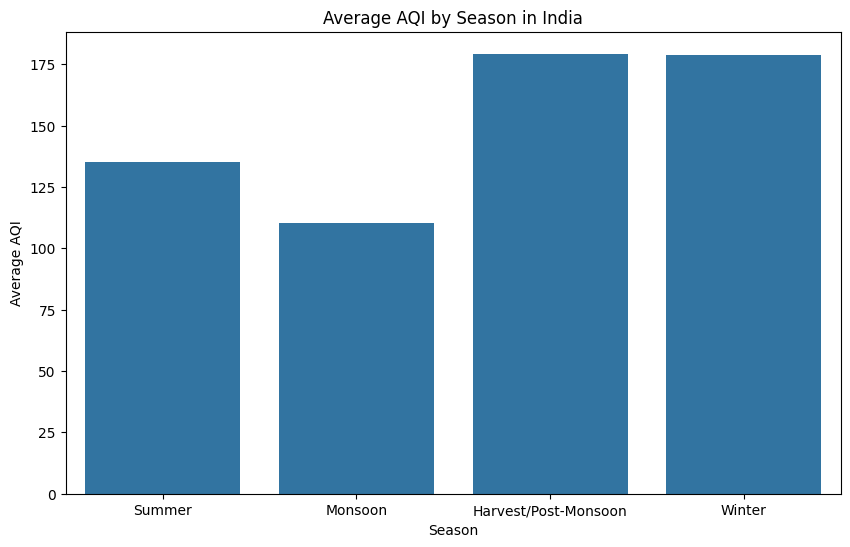

In [48]:
city['Month'] = city['Date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    elif month in [10, 11, 12]:
        return 'Harvest/Post-Monsoon'
    else:
        return 'Winter'

city['Season'] = city['Month'].apply(get_season)

seasonal_aqi = city.groupby('Season')['AQI'].mean().reset_index()

season_order = ['Summer', 'Monsoon', 'Harvest/Post-Monsoon', 'Winter']

seasonal_aqi['Season'] = pd.Categorical(
    seasonal_aqi['Season'],
    categories=season_order,
    ordered=True
)

seasonal_aqi = seasonal_aqi.sort_values('Season')

plt.figure(figsize=(10,6))

sns.barplot(data=seasonal_aqi,
            x='Season',
            y='AQI')

plt.title('Average AQI by Season in India')
plt.xlabel('Season')
plt.ylabel('Average AQI')

plt.show()

Seasons were created from the Date column and the average AQI was calculated for each season. A bar chart was chosen 
because it makes it easy to compare pollution levels across seasons and identify which season has the highest average AQI.

1)The Harvest/Post-Monsoon season has the highest average AQI (around 180), indicating the poorest air quality of the year.
2)The Monsoon season has the lowest average AQI (around 110), suggesting that rainfall helps reduce air pollution.

task 8

The air quality dataset contains daily observations at the city level, while the crop dataset contains agricultural records at the state level. These datasets cannot be merged directly because they are recorded at different levels of detail.

To make them compatible, the air quality data was aggregated from city level to state level by calculating the average AQI for each state. Similarly, the crop dataset was aggregated to state level by calculating the average cultivated area and crop production for each state.

This created a common state-level structure that allowed both datasets to be merged reliably and used for relationship analysis.

In [56]:
state_aqi = city.groupby('State')['AQI'].mean().reset_index()

state_crop = crop.groupby('State_Name')[['Area', 'Production']].mean().reset_index()

merged_data = pd.merge(
    state_crop,
    state_aqi,
    left_on='State_Name',
    right_on='State',
    how='inner'
)

print("Merged Dataset Shape:", merged_data.shape)

Merged Dataset Shape: (20, 5)


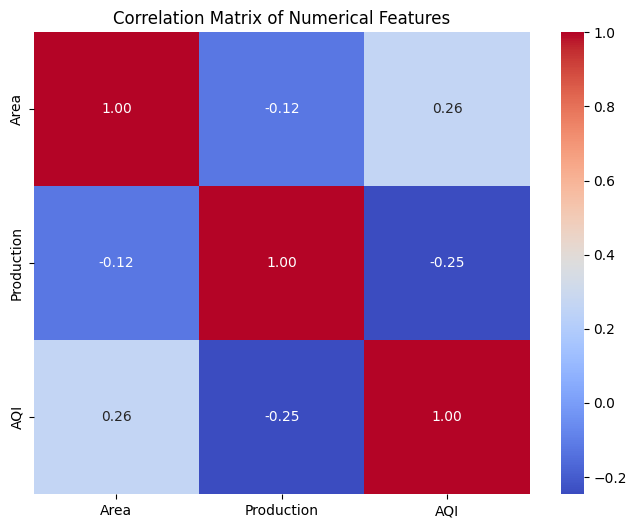

In [57]:
corr_matrix = merged_data[['Area', 'Production', 'AQI']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

Relationship 1

AQI and Production have a negative correlation (-0.25). This suggests that states with poorer air quality tend to have slightly lower crop production. A possible reason is that air pollution can affect plant growth, reduce photosynthesis, and negatively impact agricultural productivity.

Relationship 2

AQI and Area have a positive correlation (0.26). This indicates that states with larger cultivated areas tend to have slightly higher AQI levels. One possible reason is that agricultural activities such as crop residue burning, use of machinery, and transportation may contribute to increased air pollution.

The correlations are relatively weak, which means the relationships are not very strong. Correlation helps identify associations between variables, but it does not prove that one variable directly causes changes in another. Other factors such as rainfall, soil quality, irrigation, and farming practices may also influence crop production.

task 9

### Briefing for the State Environment Minister

Dear Minister,

Our analysis of air quality and crop production data found three important results. First, air quality has generally improved between 2015 and 2020, as average pollution levels have decreased over time. This suggests that efforts to control pollution may be helping.

Second, pollution levels are highest during the October–December harvest season. This indicates that seasonal farming activities, including crop residue burning, may contribute to poorer air quality during this period.

Third, states with higher pollution levels tend to have slightly lower crop production. Although this relationship is weak, it suggests that poor air quality may affect farming and crop growth.

For farmers, these findings mean that reducing pollution could help create better growing conditions and support agricultural productivity.

Based on the data, I recommend increasing support for alternatives to crop residue burning during the harvest season. This could reduce seasonal pollution while helping farmers manage agricultural waste more effectively.

One important limitation is that the data shows a relationship between pollution and crop production, but it does not prove that pollution directly causes lower crop yields. Other factors such as rainfall, soil quality, and farming practices may also influence production.

Thank you.


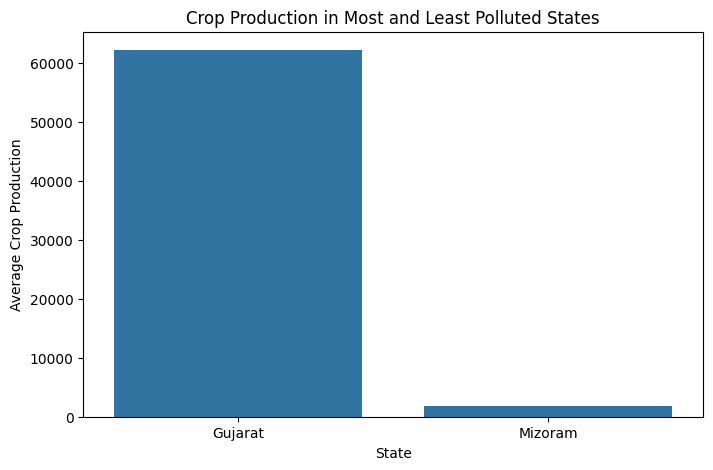

In [61]:
# task A
highest_aqi_state = merged_data.loc[merged_data['AQI'].idxmax()]
lowest_aqi_state = merged_data.loc[merged_data['AQI'].idxmin()]

comparison = pd.DataFrame({
    'State': [highest_aqi_state['State_Name'],
              lowest_aqi_state['State_Name']],
    'Production': [highest_aqi_state['Production'],
                   lowest_aqi_state['Production']]
})

plt.figure(figsize=(8,5))

sns.barplot(data=comparison,
            x='State',
            y='Production')

plt.title('Crop Production in Most and Least Polluted States')
plt.xlabel('State')
plt.ylabel('Average Crop Production')

plt.show()

The most polluted and least polluted states were compared using their average crop production. The results show whether states with poorer air quality consistently produce fewer crops. If the least polluted state has higher production, the hypothesis is supported. However, if the difference is small or the more polluted state has similar production, the relationship is more complicated. Factors such as rainfall, irrigation, soil quality, and farming practices may also influence crop production.

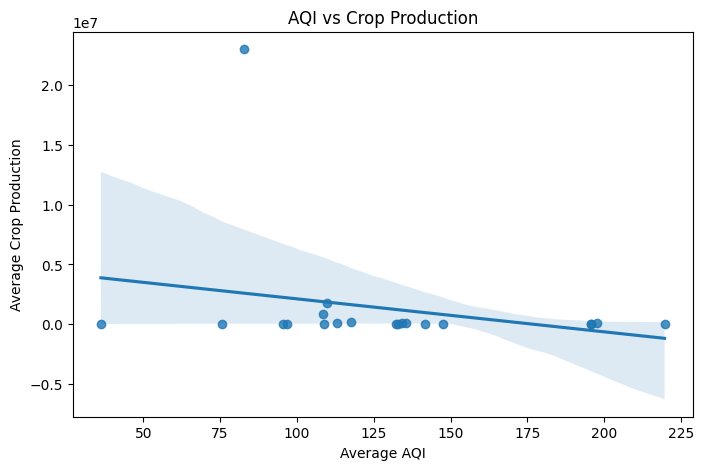

Correlation: -0.24657886802043602


In [62]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=merged_data,
    x='AQI',
    y='Production'
)

plt.title('AQI vs Crop Production')
plt.xlabel('Average AQI')
plt.ylabel('Average Crop Production')

plt.show()

corr_coef = merged_data['AQI'].corr(
    merged_data['Production']
)

print("Correlation:", corr_coef)

The correlation coefficient measures the strength and direction of the relationship between AQI and crop production. A value close to 0 indicates a weak relationship, while values closer to -1 or 1 indicate stronger relationships. In this analysis, the correlation is weak, suggesting that air quality alone cannot explain differences in crop production. Correlation does not prove causation. Other factors such as rainfall, irrigation, soil quality, and economic conditions may also affect agricultural output.